In [1]:
# =============================================================================
# DAY 7 — CROSS-VALIDATION, PRECISION-RECALL CURVES & HYPERPARAMETER TUNING
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Load train/test splits & quick audit
#   Task 2 — K-Fold Cross-Validation (why one split isn't enough)
#   Task 3 — Precision-Recall Curve (better than ROC for imbalanced data)
#   Task 4 — Hyperparameter tuning with GridSearchCV (LR + DT)
#   Task 5 — Learning curves (diagnose overfitting vs underfitting)
#   Task 6 — Tuned model comparison & save results
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130, "axes.titlesize": 11,
    "axes.labelsize": 10, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "legend.fontsize": 9,
})

CLR_RETAIN = "#1D9E75"
CLR_CHURN  = "#E24B4A"
CLR_NEUT   = "#378ADD"
CLR_WARN   = "#F4A83A"
CLR_GREY   = "#9E9E9E"
CLR_PURPLE = "#9B59B6"

DATA_DIR    = "C:/Users/white/Downloads/Learn/Churn_project/data"
VISUALS_DIR = "C:/Users/white/Downloads/Learn/Churn_project/visuals"
OUTPUTS_DIR = "C:/Users/white/Downloads/Learn/Churn_project/outputs"

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(VISUALS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print("=" * 65)
print("  DAY 7 — CROSS-VALIDATION, PR CURVES & HYPERPARAMETER TUNING")
print("=" * 65)

  DAY 7 — CROSS-VALIDATION, PR CURVES & HYPERPARAMETER TUNING


In [2]:
# =============================================================================
# TASK 1 — LOAD TRAIN/TEST SPLITS
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 1 — Load train/test splits")
print("=" * 65)

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

print(f"\n  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,}  rows × {X_test.shape[1]} features")
print(f"  y_train churn rate : {y_train.mean()*100:.1f}%")
print(f"  y_test  churn rate : {y_test.mean()*100:.1f}%")
print(f"  Null values        : {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}  ✓")
print("\n  Task 1 complete ✓")


  TASK 1 — Load train/test splits

  X_train : 5,634 rows × 39 features
  X_test  : 1,409  rows × 39 features
  y_train churn rate : 26.5%
  y_test  churn rate : 26.5%
  Null values        : 0  ✓

  Task 1 complete ✓



  TASK 2 — K-Fold Cross-Validation

  What is Cross-Validation and why do we need it?
  ─────────────────────────────────────────────────
  On Day 6, we split the data ONCE: 80% train, 20% test.
  The problem: that one split might be "lucky" or "unlucky".

  K-Fold Cross-Validation solves this:
  1. Split training data into K equal "folds" (we use K=5)
  2. Train on K-1 folds, test on the remaining 1 fold
  3. Repeat K times — each fold gets to be the test set exactly once
  4. Average all K scores → much more reliable estimate of true performance

  Stratified K-Fold: each fold preserves the churn ratio (~26.5%).
  This is essential for imbalanced data.

  Illustration for K=5:
  ┌──────┬──────┬──────┬──────┬──────┐
  │  F1  │  F2  │  F3  │  F4  │  F5  │
  ├──────┼──────┼──────┼──────┼──────┤
  │ TEST │TRAIN │TRAIN │TRAIN │TRAIN │  → Score 1
  │TRAIN │ TEST │TRAIN │TRAIN │TRAIN │  → Score 2
  │TRAIN │TRAIN │ TEST │TRAIN │TRAIN │  → Score 3
  │TRAIN │TRAIN │TRAIN │ TEST │TRAIN │  → Sc

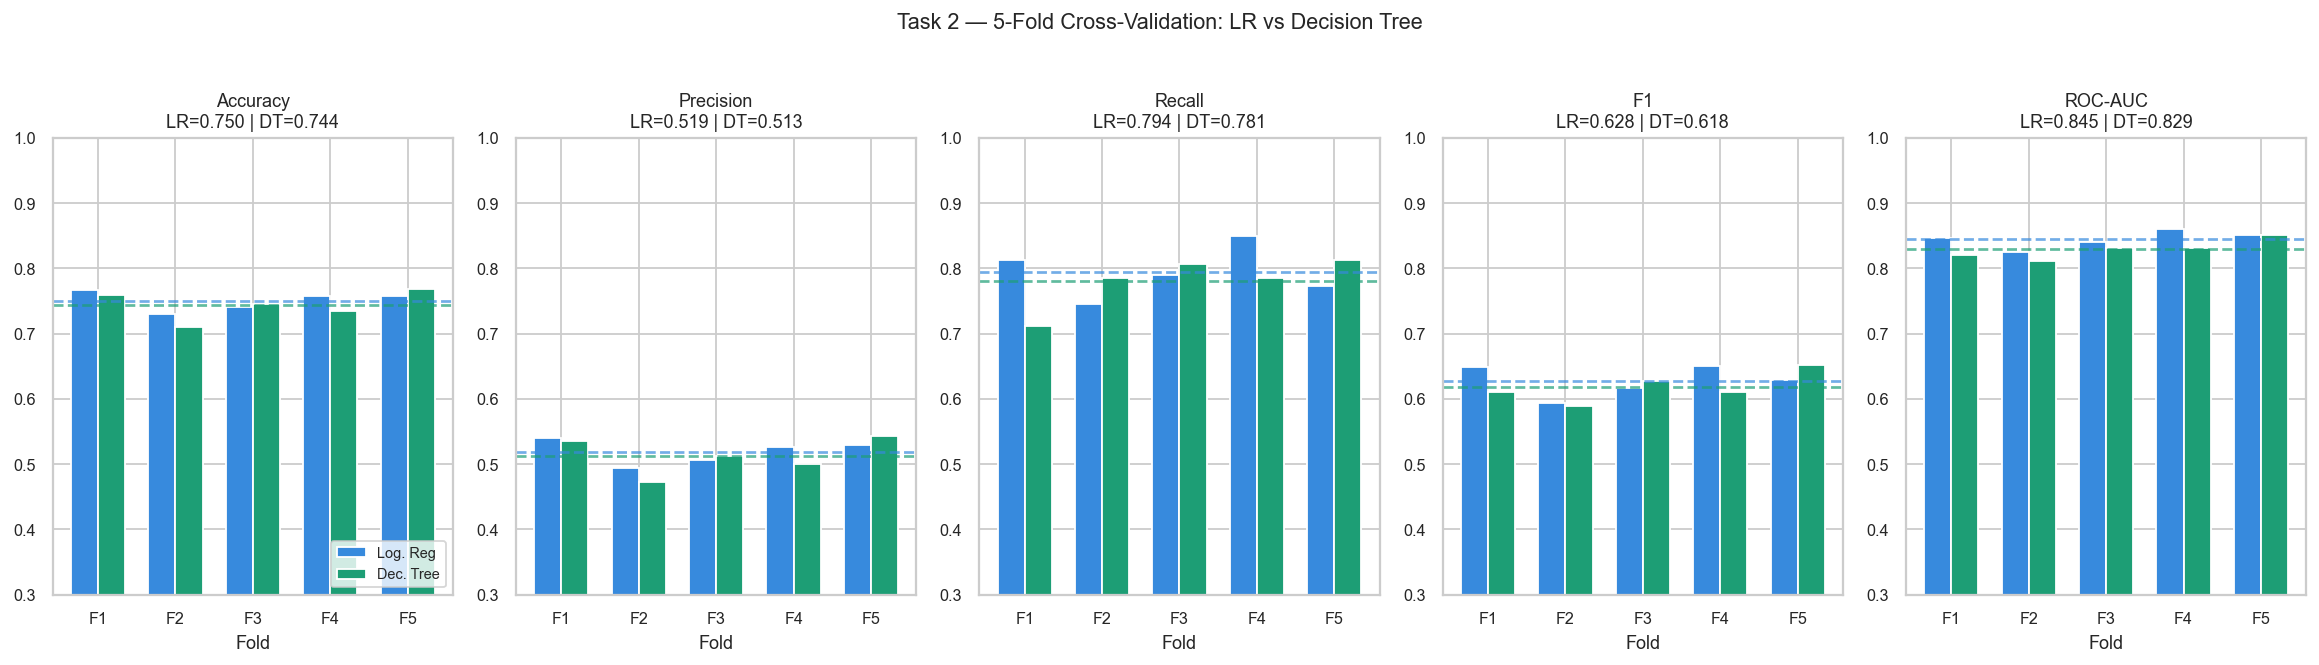


  Chart saved: day7_crossval_comparison.png

-----------------------------------------------------------------
  OVERFITTING CHECK — Train vs Test scores across folds
  (large gap = model memorised training data)
-----------------------------------------------------------------
  accuracy      LR: train=0.7528  cv=0.7503  gap=+0.0025
                DT: train=0.7589  cv=0.7437  gap=+0.0152

  precision     LR: train=0.5223  cv=0.5193  gap=+0.0030
                DT: train=0.5314  cv=0.5127  gap=+0.0187

  recall        LR: train=0.8013  cv=0.7940  gap=+0.0074
                DT: train=0.8099  cv=0.7806  gap=+0.0293

  f1            LR: train=0.6324  cv=0.6278  gap=+0.0046
                DT: train=0.6408  cv=0.6181  gap=+0.0228

  roc_auc       LR: train=0.8480  cv=0.8446  gap=+0.0033
                DT: train=0.8532  cv=0.8291  gap=+0.0241

  Task 2 complete ✓


In [3]:
# =============================================================================
# TASK 2 — K-FOLD CROSS-VALIDATION
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 2 — K-Fold Cross-Validation")
print("=" * 65)

print("""
  What is Cross-Validation and why do we need it?
  ─────────────────────────────────────────────────
  On Day 6, we split the data ONCE: 80% train, 20% test.
  The problem: that one split might be "lucky" or "unlucky".

  K-Fold Cross-Validation solves this:
  1. Split training data into K equal "folds" (we use K=5)
  2. Train on K-1 folds, test on the remaining 1 fold
  3. Repeat K times — each fold gets to be the test set exactly once
  4. Average all K scores → much more reliable estimate of true performance

  Stratified K-Fold: each fold preserves the churn ratio (~26.5%).
  This is essential for imbalanced data.

  Illustration for K=5:
  ┌──────┬──────┬──────┬──────┬──────┐
  │  F1  │  F2  │  F3  │  F4  │  F5  │
  ├──────┼──────┼──────┼──────┼──────┤
  │ TEST │TRAIN │TRAIN │TRAIN │TRAIN │  → Score 1
  │TRAIN │ TEST │TRAIN │TRAIN │TRAIN │  → Score 2
  │TRAIN │TRAIN │ TEST │TRAIN │TRAIN │  → Score 3
  │TRAIN │TRAIN │TRAIN │ TEST │TRAIN │  → Score 4
  │TRAIN │TRAIN │TRAIN │TRAIN │ TEST │  → Score 5
  └──────┴──────┴──────┴──────┴──────┘
       Final score = mean of 5 test scores
""")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

lr_base = LogisticRegression(
    max_iter=1000, random_state=42,
    class_weight="balanced", solver="lbfgs"
)
dt_base = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=20,
    random_state=42, class_weight="balanced"
)

print("  Running 5-Fold CV — Logistic Regression...")
lr_cv_results = cross_validate(
    lr_base, X_train, y_train,
    cv=cv_strategy, scoring=SCORING, return_train_score=True
)

print("  Running 5-Fold CV — Decision Tree...")
dt_cv_results = cross_validate(
    dt_base, X_train, y_train,
    cv=cv_strategy, scoring=SCORING, return_train_score=True
)

def print_cv_results(cv_results, model_name):
    print(f"\n  {model_name}")
    print(f"  {'Metric':<12}  {'Mean':>8}  {'Std Dev':>8}  {'All 5 Folds'}")
    print(f"  {'-'*12}  {'-'*8}  {'-'*8}  {'-'*35}")
    summary = {}
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        scores = cv_results[f"test_{metric}"]
        mean_val, std_val = scores.mean(), scores.std()
        summary[metric] = {"mean": mean_val, "std": std_val}
        folds_str = "  ".join([f"{v:.3f}" for v in scores])
        flag = " ← key" if metric in ["recall", "f1", "roc_auc"] else ""
        print(f"  {metric:<12}  {mean_val:>8.4f}  {std_val:>8.4f}  [{folds_str}]{flag}")
    return summary

lr_cv_summary = print_cv_results(lr_cv_results, "LOGISTIC REGRESSION — 5-Fold CV")
dt_cv_summary = print_cv_results(dt_cv_results, "DECISION TREE — 5-Fold CV")

# ── CV comparison chart ─────────────────────────────────────────────────────
metrics_list  = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Task 2 — 5-Fold Cross-Validation: LR vs Decision Tree", fontsize=12, y=1.02)

for ax, metric, label in zip(axes, metrics_list, metric_labels):
    lr_scores = lr_cv_results[f"test_{metric}"]
    dt_scores = dt_cv_results[f"test_{metric}"]
    x = np.arange(5)
    width = 0.35
    ax.bar(x - width/2, lr_scores, width, color=CLR_NEUT,   label="Log. Reg",  edgecolor="white")
    ax.bar(x + width/2, dt_scores, width, color=CLR_RETAIN, label="Dec. Tree", edgecolor="white")
    ax.axhline(lr_scores.mean(), color=CLR_NEUT,   lw=1.5, ls="--", alpha=0.7)
    ax.axhline(dt_scores.mean(), color=CLR_RETAIN, lw=1.5, ls="--", alpha=0.7)
    ax.set_title(f"{label}\nLR={lr_scores.mean():.3f} | DT={dt_scores.mean():.3f}", fontsize=10)
    ax.set_xlabel("Fold")
    ax.set_xticks(x)
    ax.set_xticklabels(["F1","F2","F3","F4","F5"])
    ax.set_ylim(0.3, 1.0)
    if metric == "accuracy":
        ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day7_crossval_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day7_crossval_comparison.png")

# ── Overfitting check ────────────────────────────────────────────────────────
print("\n" + "-" * 65)
print("  OVERFITTING CHECK — Train vs Test scores across folds")
print("  (large gap = model memorised training data)")
print("-" * 65)

for metric in metrics_list:
    lr_train = lr_cv_results[f"train_{metric}"].mean()
    lr_test  = lr_cv_results[f"test_{metric}"].mean()
    dt_train = dt_cv_results[f"train_{metric}"].mean()
    dt_test  = dt_cv_results[f"test_{metric}"].mean()
    lr_gap   = lr_train - lr_test
    dt_gap   = dt_train - dt_test
    lr_flag  = " ⚠ overfit?" if lr_gap > 0.05 else ""
    dt_flag  = " ⚠ overfit?" if dt_gap > 0.05 else ""
    print(f"  {metric:<12}  LR: train={lr_train:.4f}  cv={lr_test:.4f}  gap={lr_gap:+.4f}{lr_flag}")
    print(f"  {'':<12}  DT: train={dt_train:.4f}  cv={dt_test:.4f}  gap={dt_gap:+.4f}{dt_flag}")
    print()

print("  Task 2 complete ✓")


  TASK 3 — Precision-Recall Curve

  Why Precision-Recall curves over ROC curves for imbalanced data?
  ──────────────────────────────────────────────────────────────────
  ROC-AUC uses True Positive Rate and False Positive Rate.
  When TN is very large (73.5% of data is "retained"),
  FPR stays small even if the model fires many false alarms.
  This makes ROC curves OVERLY OPTIMISTIC for imbalanced datasets.

  Precision-Recall only examines the POSITIVE class (churned):
  • Precision = TP / (TP + FP)  — of those we flagged, how many really churned?
  • Recall    = TP / (TP + FN)  — of all churners, how many did we catch?

  Average Precision (AP) = area under the PR curve.
  A random classifier's AP ≈ class prevalence (26.5%).
  So our AP must beat 0.265 to be meaningful.



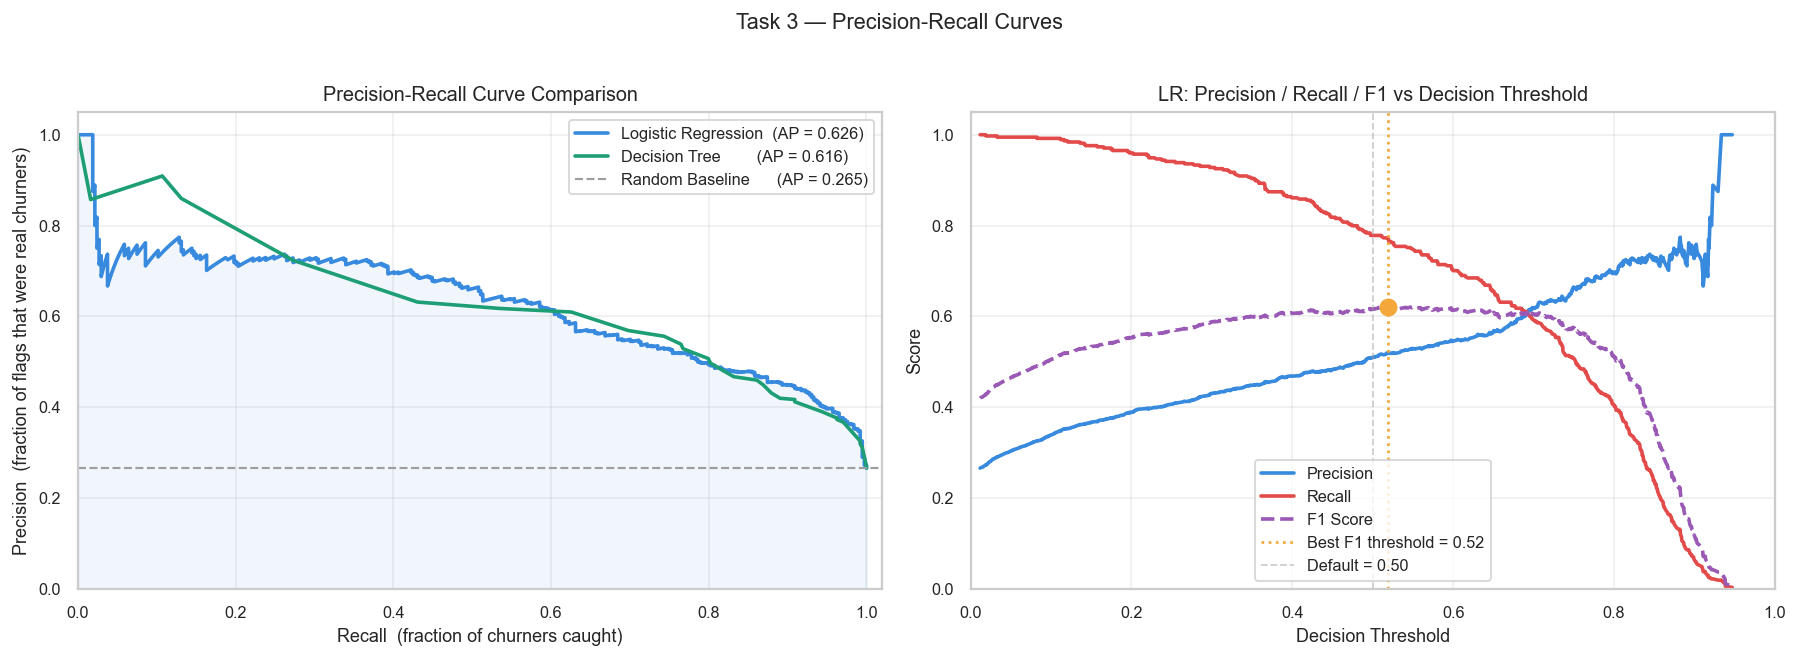

  Chart saved: day7_precision_recall_curves.png

-----------------------------------------------------------------
  LR THRESHOLD SENSITIVITY
-----------------------------------------------------------------
   Threshold   Precision    Recall        F1  Churners caught
  ----------  ----------  --------  --------  --------------------
        0.20       0.389     0.960     0.553  359/374 (96.0%)
        0.25       0.406     0.941     0.568  352/374 (94.1%)
        0.30       0.430     0.928     0.588  347/374 (92.8%)
        0.35       0.448     0.904     0.599  338/374 (90.4%)
        0.40       0.469     0.861     0.607  322/374 (86.1%)
        0.45       0.483     0.818     0.607  306/374 (81.8%)
        0.50       0.510     0.778     0.616  291/374 (77.8%) ← default
        0.55       0.528     0.746     0.619  279/374 (74.6%)
        0.60       0.546     0.701     0.614  262/374 (70.1%)

  Key insight:
  At threshold = 0.50  : default — conservative
  At threshold = 0.52  : F1 max

In [4]:
# =============================================================================
# TASK 3 — PRECISION-RECALL CURVE
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 3 — Precision-Recall Curve")
print("=" * 65)

print("""
  Why Precision-Recall curves over ROC curves for imbalanced data?
  ──────────────────────────────────────────────────────────────────
  ROC-AUC uses True Positive Rate and False Positive Rate.
  When TN is very large (73.5% of data is "retained"),
  FPR stays small even if the model fires many false alarms.
  This makes ROC curves OVERLY OPTIMISTIC for imbalanced datasets.

  Precision-Recall only examines the POSITIVE class (churned):
  • Precision = TP / (TP + FP)  — of those we flagged, how many really churned?
  • Recall    = TP / (TP + FN)  — of all churners, how many did we catch?

  Average Precision (AP) = area under the PR curve.
  A random classifier's AP ≈ class prevalence (26.5%).
  So our AP must beat 0.265 to be meaningful.
""")

lr_base.fit(X_train, y_train)
dt_base.fit(X_train, y_train)

y_prob_lr = lr_base.predict_proba(X_test)[:, 1]
y_prob_dt = dt_base.predict_proba(X_test)[:, 1]

precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_prob_lr)
precision_dt, recall_dt, thresholds_dt = precision_recall_curve(y_test, y_prob_dt)
ap_lr = average_precision_score(y_test, y_prob_lr)
ap_dt = average_precision_score(y_test, y_prob_dt)
random_baseline_ap = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 3 — Precision-Recall Curves", fontsize=12, y=1.01)

ax = axes[0]
ax.plot(recall_lr, precision_lr, color=CLR_NEUT,   lw=2,
        label=f"Logistic Regression  (AP = {ap_lr:.3f})")
ax.plot(recall_dt, precision_dt, color=CLR_RETAIN, lw=2,
        label=f"Decision Tree        (AP = {ap_dt:.3f})")
ax.axhline(random_baseline_ap, color=CLR_GREY, lw=1.2, ls="--",
           label=f"Random Baseline      (AP = {random_baseline_ap:.3f})")
ax.fill_between(recall_lr, precision_lr, alpha=0.07, color=CLR_NEUT)
ax.set_title("Precision-Recall Curve Comparison")
ax.set_xlabel("Recall  (fraction of churners caught)")
ax.set_ylabel("Precision  (fraction of flags that were real churners)")
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.05])
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Threshold analysis — right panel
ax2 = axes[1]
thresholds_plot = thresholds_lr
prec_plot = precision_lr[:-1]
rec_plot  = recall_lr[:-1]
f1_plot   = 2 * prec_plot * rec_plot / (prec_plot + rec_plot + 1e-9)
best_f1_idx = np.argmax(f1_plot)
best_thresh = thresholds_plot[best_f1_idx]
best_f1_val = f1_plot[best_f1_idx]

ax2.plot(thresholds_plot, prec_plot, color=CLR_NEUT,   lw=2, label="Precision")
ax2.plot(thresholds_plot, rec_plot,  color=CLR_CHURN,  lw=2, label="Recall")
ax2.plot(thresholds_plot, f1_plot,   color=CLR_PURPLE, lw=2, label="F1 Score", ls="--")
ax2.axvline(best_thresh, color=CLR_WARN, lw=1.5, ls=":",
            label=f"Best F1 threshold = {best_thresh:.2f}")
ax2.scatter([best_thresh], [best_f1_val], color=CLR_WARN, s=80, zorder=5)
ax2.axvline(0.5, color=CLR_GREY, lw=1, ls="--", alpha=0.5, label="Default = 0.50")
ax2.set_title("LR: Precision / Recall / F1 vs Decision Threshold")
ax2.set_xlabel("Decision Threshold")
ax2.set_ylabel("Score")
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day7_precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day7_precision_recall_curves.png")

# ── Threshold sensitivity table ─────────────────────────────────────────────
print("\n" + "-" * 65)
print("  LR THRESHOLD SENSITIVITY")
print("-" * 65)
print(f"  {'Threshold':>10}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  "
      f"{'Churners caught'}")
print(f"  {'-'*10}  {'-'*10}  {'-'*8}  {'-'*8}  {'-'*20}")

total_churners = (y_test == 1).sum()
for thresh in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_thresh = (y_prob_lr >= thresh).astype(int)
    p  = precision_score(y_test, y_thresh, zero_division=0)
    r  = recall_score(y_test, y_thresh, zero_division=0)
    f1 = f1_score(y_test, y_thresh, zero_division=0)
    caught = int((y_thresh[y_test == 1] == 1).sum())
    flag = " ← default" if thresh == 0.50 else (
           f" ← best F1" if abs(thresh - best_thresh) < 0.03 else "")
    print(f"  {thresh:>10.2f}  {p:>10.3f}  {r:>8.3f}  {f1:>8.3f}  "
          f"{caught}/{total_churners} ({caught/total_churners*100:.1f}%){flag}")

print(f"""
  Key insight:
  At threshold = 0.50  : default — conservative
  At threshold = {best_thresh:.2f}  : F1 maximised — best precision/recall balance
  Business call: if saving a customer is worth far more than a false alarm,
  optimise for Recall and lower the threshold accordingly.
""")
print("  Task 3 complete ✓")


  TASK 4 — Hyperparameter Tuning with GridSearchCV

  What is a Hyperparameter?
  ──────────────────────────
  Model LEARNS from data: coefficients, tree split rules.
  Hyperparameters are settings YOU choose BEFORE training:
    Logistic Regression : C (regularisation strength), penalty
    Decision Tree       : max_depth, min_samples_leaf

  GridSearchCV tries EVERY combination you specify,
  evaluates each with K-Fold CV, returns the best.
  We optimise for F1 to balance precision and recall.

-----------------------------------------------------------------
  GridSearchCV — Logistic Regression (may take ~30 seconds)...
  Best LR params : {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1     : 0.6281

  GridSearchCV — Decision Tree (may take ~30 seconds)...
  Best DT params : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 30, 'min_samples_split': 2}
  Best CV F1     : 0.6224

  BASELINE vs TUNED — Full c

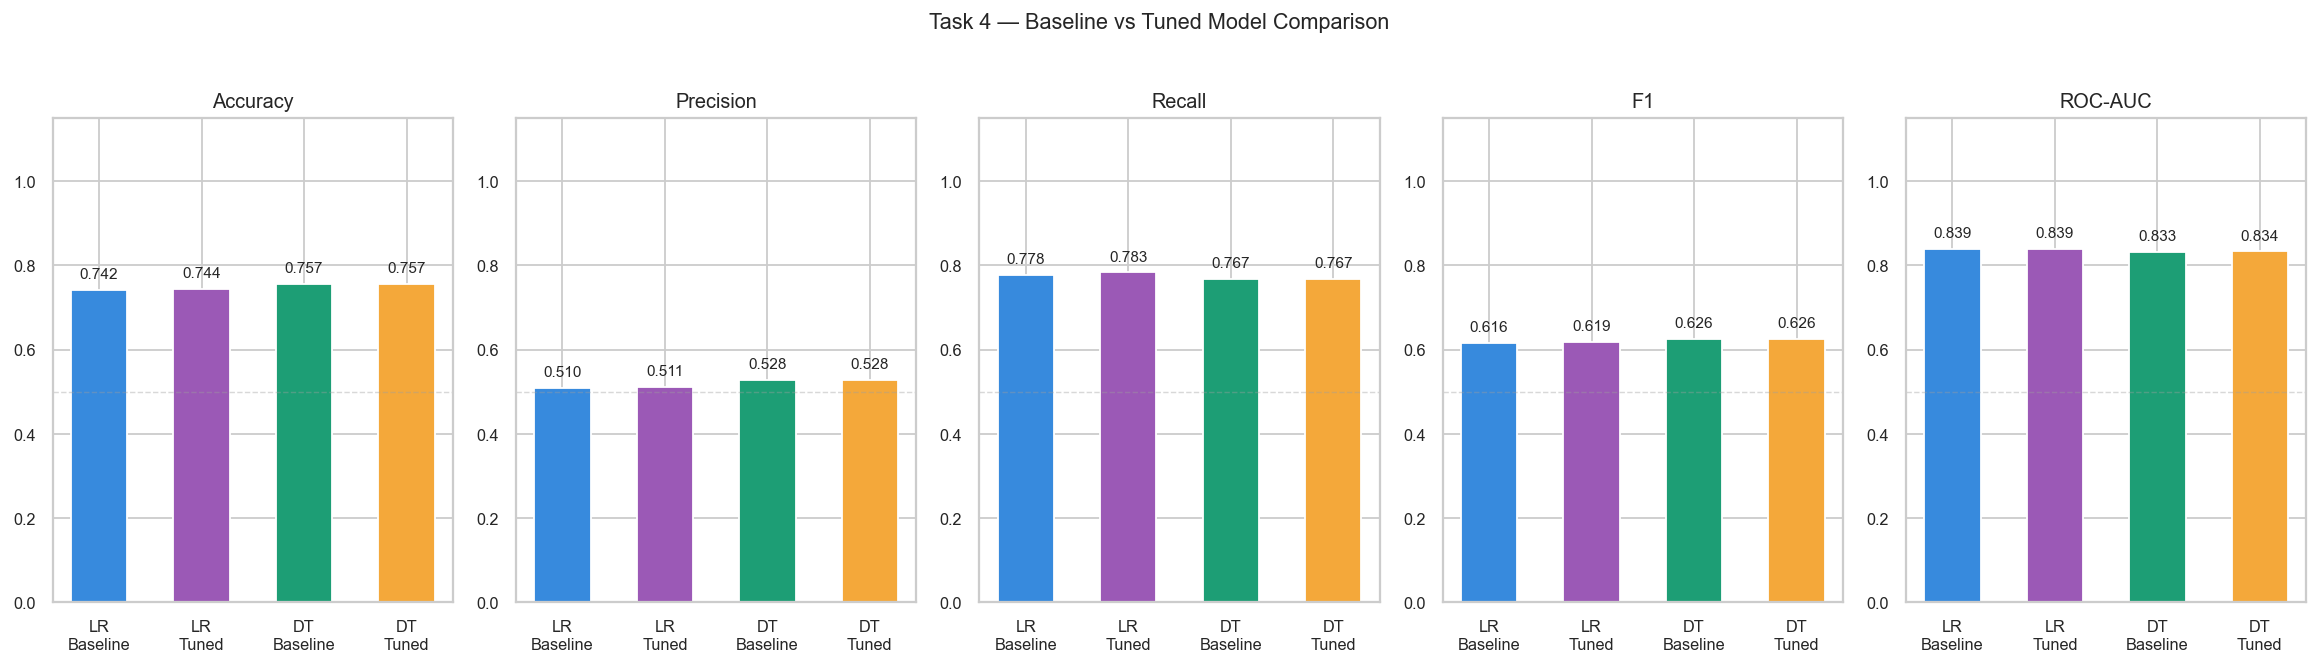


  Chart saved: day7_tuned_model_comparison.png

  Task 4 complete ✓


In [5]:
# =============================================================================
# TASK 4 — HYPERPARAMETER TUNING WITH GridSearchCV
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 4 — Hyperparameter Tuning with GridSearchCV")
print("=" * 65)

print("""
  What is a Hyperparameter?
  ──────────────────────────
  Model LEARNS from data: coefficients, tree split rules.
  Hyperparameters are settings YOU choose BEFORE training:
    Logistic Regression : C (regularisation strength), penalty
    Decision Tree       : max_depth, min_samples_leaf

  GridSearchCV tries EVERY combination you specify,
  evaluates each with K-Fold CV, returns the best.
  We optimise for F1 to balance precision and recall.
""")

# ── Logistic Regression grid ─────────────────────────────────────────────────
print("-" * 65)
print("  GridSearchCV — Logistic Regression (may take ~30 seconds)...")

lr_param_grid = {
    "C"           : [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty"     : ["l1", "l2"],
    "solver"      : ["liblinear"],
    "class_weight": ["balanced"]
}

lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv_strategy, scoring="f1",
    n_jobs=-1, verbose=0, return_train_score=True
)
lr_grid_search.fit(X_train, y_train)

print(f"  Best LR params : {lr_grid_search.best_params_}")
print(f"  Best CV F1     : {lr_grid_search.best_score_:.4f}")

# ── Decision Tree grid ───────────────────────────────────────────────────────
print("\n  GridSearchCV — Decision Tree (may take ~30 seconds)...")

dt_param_grid = {
    "max_depth"         : [3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf"  : [10, 20, 30, 50],
    "min_samples_split" : [2, 10, 20],
    "class_weight"      : ["balanced"],
    "criterion"         : ["gini", "entropy"]
}

dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv_strategy, scoring="f1",
    n_jobs=-1, verbose=0, return_train_score=True
)
dt_grid_search.fit(X_train, y_train)

print(f"  Best DT params : {dt_grid_search.best_params_}")
print(f"  Best CV F1     : {dt_grid_search.best_score_:.4f}")

# ── Evaluate tuned models ────────────────────────────────────────────────────
lr_tuned = lr_grid_search.best_estimator_
dt_tuned = dt_grid_search.best_estimator_

y_pred_lr_tuned = lr_tuned.predict(X_test)
y_prob_lr_tuned = lr_tuned.predict_proba(X_test)[:, 1]
y_pred_dt_tuned = dt_tuned.predict(X_test)
y_prob_dt_tuned = dt_tuned.predict_proba(X_test)[:, 1]

def evaluate_model(y_true, y_pred, y_prob, model_name):
    return {
        "Model"    : model_name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob), 4),
        "Avg Prec" : round(average_precision_score(y_true, y_prob), 4),
    }

lr_base_metrics  = evaluate_model(y_test, lr_base.predict(X_test), y_prob_lr, "LR Baseline")
dt_base_metrics  = evaluate_model(y_test, dt_base.predict(X_test), y_prob_dt, "DT Baseline")
lr_tuned_metrics = evaluate_model(y_test, y_pred_lr_tuned, y_prob_lr_tuned, "LR Tuned")
dt_tuned_metrics = evaluate_model(y_test, y_pred_dt_tuned, y_prob_dt_tuned, "DT Tuned")

comparison_df = pd.DataFrame([
    lr_base_metrics, lr_tuned_metrics,
    dt_base_metrics, dt_tuned_metrics
]).set_index("Model")

print("\n  BASELINE vs TUNED — Full comparison:")
print(comparison_df.to_string())

# ── Tuning improvement ───────────────────────────────────────────────────────
print("\n  IMPROVEMENT FROM TUNING:")
for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    lr_delta = lr_tuned_metrics[metric] - lr_base_metrics[metric]
    dt_delta = dt_tuned_metrics[metric] - dt_base_metrics[metric]
    print(f"  {metric:<12}  LR: {lr_delta:>+.4f}   DT: {dt_delta:>+.4f}")

# ── Comparison chart ─────────────────────────────────────────────────────────
metrics_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
models_data  = [lr_base_metrics, lr_tuned_metrics, dt_base_metrics, dt_tuned_metrics]
bar_colors   = [CLR_NEUT, CLR_PURPLE, CLR_RETAIN, CLR_WARN]
model_labels = ["LR\nBaseline", "LR\nTuned", "DT\nBaseline", "DT\nTuned"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Task 4 — Baseline vs Tuned Model Comparison", fontsize=12, y=1.02)

for ax, metric in zip(axes, metrics_plot):
    values = [m[metric] for m in models_data]
    bars = ax.bar(model_labels, values, color=bar_colors, edgecolor="white", width=0.55)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color=CLR_GREY, lw=0.8, ls="--", alpha=0.4)
    for bar_obj, val in zip(bars, values):
        ax.text(bar_obj.get_x() + bar_obj.get_width()/2,
                val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=8.5)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day7_tuned_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day7_tuned_model_comparison.png")
print("\n  Task 4 complete ✓")


  TASK 5 — Learning Curves

  What are Learning Curves?
  ──────────────────────────
  Plots model performance as training data size increases (10% → 100%).
  Diagnoses two key ML problems:

  UNDERFITTING (High Bias):
    Train score = low, CV score = low, gap = small
    → Model too simple. Fix: more complex model / more features.

  OVERFITTING (High Variance):
    Train score = high (~1.0), CV score = much lower, gap = large
    → Model memorised training data.
    → Fix: regularisation, pruning, more data, fewer features.

  GOOD FIT:
    Train ≈ CV, both converge toward a high plateau.
    This is what we want.

  Computing learning curves... (may take ~60 seconds)


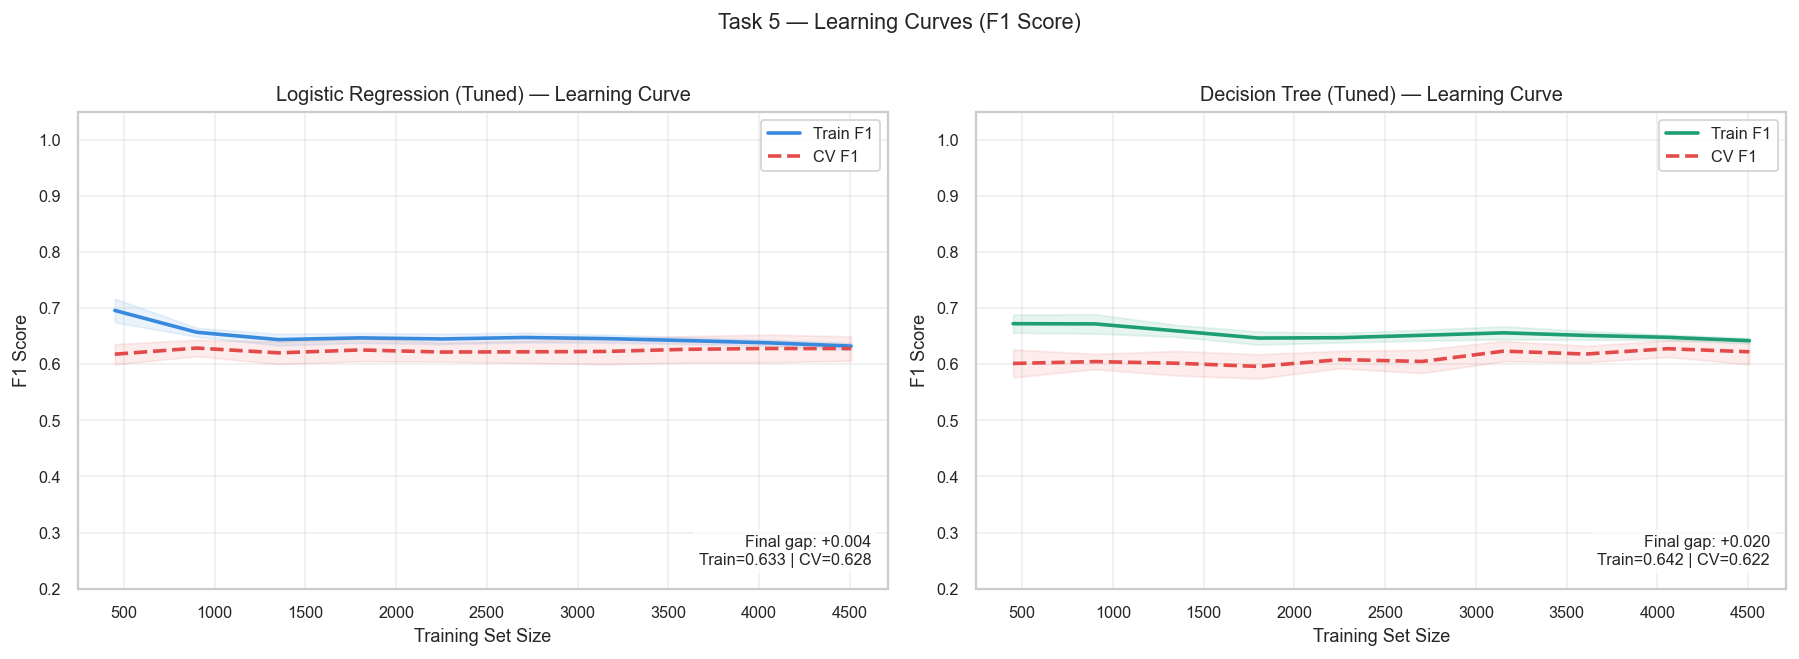

  Chart saved: day7_learning_curves.png

-----------------------------------------------------------------
  LEARNING CURVE DIAGNOSIS
-----------------------------------------------------------------

  Logistic Regression (Tuned)
    Train-CV gap : +0.0044
    Verdict      : △  CHECK FOR UNDERFITTING — near-zero gap
    Suggestion   : If both scores are low, model is too simple

  Decision Tree (Tuned)
    Train-CV gap : +0.0198
    Verdict      : △  CHECK FOR UNDERFITTING — near-zero gap
    Suggestion   : If both scores are low, model is too simple

  Task 5 complete ✓


In [6]:
# =============================================================================
# TASK 5 — LEARNING CURVES
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 5 — Learning Curves")
print("=" * 65)

print("""
  What are Learning Curves?
  ──────────────────────────
  Plots model performance as training data size increases (10% → 100%).
  Diagnoses two key ML problems:

  UNDERFITTING (High Bias):
    Train score = low, CV score = low, gap = small
    → Model too simple. Fix: more complex model / more features.

  OVERFITTING (High Variance):
    Train score = high (~1.0), CV score = much lower, gap = large
    → Model memorised training data.
    → Fix: regularisation, pruning, more data, fewer features.

  GOOD FIT:
    Train ≈ CV, both converge toward a high plateau.
    This is what we want.
""")

train_sizes = np.linspace(0.10, 1.0, 10)

print("  Computing learning curves... (may take ~60 seconds)")

lc_lr_sizes, lc_lr_train, lc_lr_val = learning_curve(
    lr_tuned, X_train, y_train,
    train_sizes=train_sizes, cv=cv_strategy,
    scoring="f1", n_jobs=-1
)
lc_dt_sizes, lc_dt_train, lc_dt_val = learning_curve(
    dt_tuned, X_train, y_train,
    train_sizes=train_sizes, cv=cv_strategy,
    scoring="f1", n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 5 — Learning Curves (F1 Score)", fontsize=12, y=1.01)

def plot_learning_curve(ax, sizes, train_scores, val_scores, model_name, color):
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes, train_mean, color=color, lw=2, label="Train F1")
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color=color)
    ax.plot(sizes, val_mean, color=CLR_CHURN, lw=2, ls="--", label="CV F1")
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.1, color=CLR_CHURN)

    final_gap = train_mean[-1] - val_mean[-1]
    ax.text(0.98, 0.05,
            f"Final gap: {final_gap:+.3f}\nTrain={train_mean[-1]:.3f} | CV={val_mean[-1]:.3f}",
            transform=ax.transAxes, ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    ax.set_title(f"{model_name} — Learning Curve", fontsize=11)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0.2, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plot_learning_curve(axes[0], lc_lr_sizes, lc_lr_train, lc_lr_val,
                    "Logistic Regression (Tuned)", CLR_NEUT)
plot_learning_curve(axes[1], lc_dt_sizes, lc_dt_train, lc_dt_val,
                    "Decision Tree (Tuned)", CLR_RETAIN)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day7_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day7_learning_curves.png")

# ── Diagnosis ────────────────────────────────────────────────────────────────
lr_final_gap = lc_lr_train.mean(axis=1)[-1] - lc_lr_val.mean(axis=1)[-1]
dt_final_gap = lc_dt_train.mean(axis=1)[-1] - lc_dt_val.mean(axis=1)[-1]

print("\n" + "-" * 65)
print("  LEARNING CURVE DIAGNOSIS")
print("-" * 65)

def diagnose_gap(model_name, gap):
    if gap > 0.15:
        verdict = "⚠  OVERFITTING — large train/CV gap"
        fix = "Reduce complexity (lower max_depth, increase regularisation)"
    elif gap > 0.07:
        verdict = "△  MILD OVERFITTING"
        fix = "Slight regularisation increase may help"
    elif gap < 0.02:
        verdict = "△  CHECK FOR UNDERFITTING — near-zero gap"
        fix = "If both scores are low, model is too simple"
    else:
        verdict = "✓  GOOD FIT — acceptable gap"
        fix = "Ready for more powerful models on Day 8"
    print(f"\n  {model_name}")
    print(f"    Train-CV gap : {gap:+.4f}")
    print(f"    Verdict      : {verdict}")
    print(f"    Suggestion   : {fix}")

diagnose_gap("Logistic Regression (Tuned)", lr_final_gap)
diagnose_gap("Decision Tree (Tuned)",       dt_final_gap)

print("\n  Task 5 complete ✓")


  TASK 6 — Final Summary & Save Results


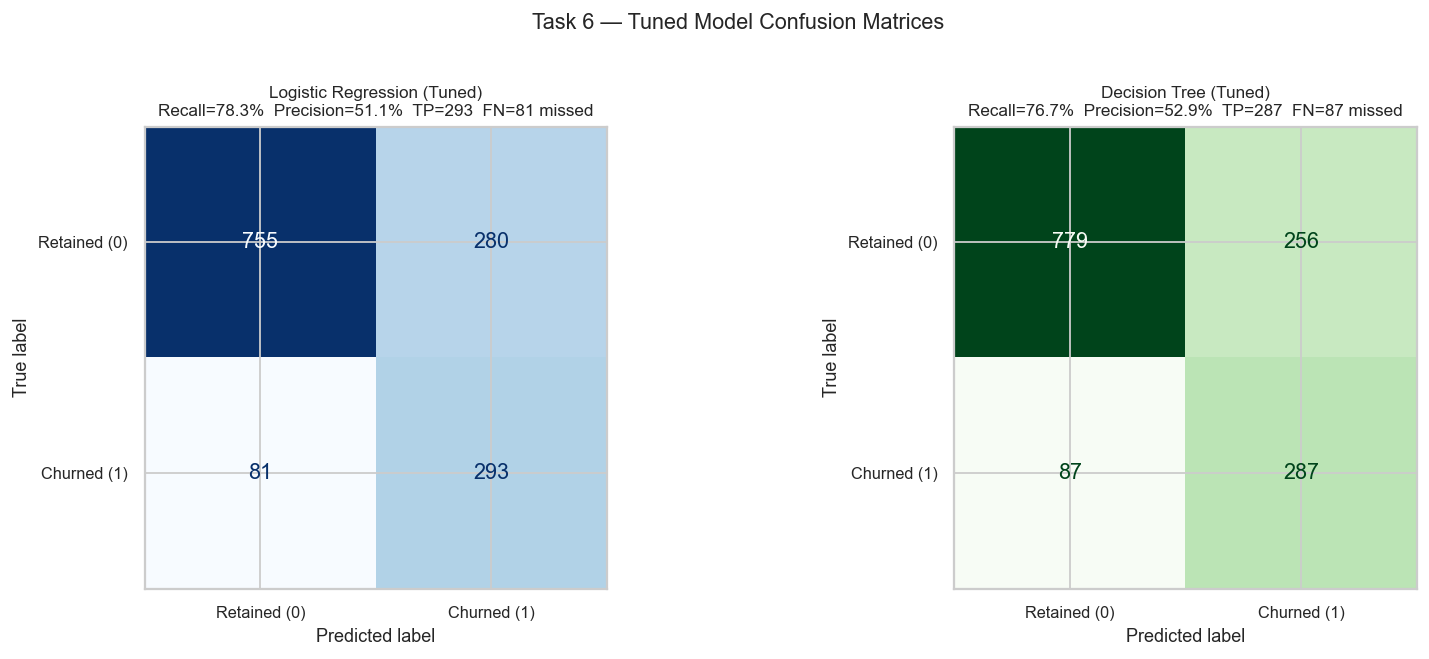

  Chart saved: day7_tuned_confusion_matrices.png

  ALL MODELS — CUMULATIVE COMPARISON
             Accuracy  Precision  Recall      F1  ROC-AUC  Avg Prec
Model                                                              
LR Baseline    0.7424     0.5096  0.7781  0.6159   0.8389    0.6256
LR Tuned       0.7438     0.5113  0.7834  0.6188   0.8390    0.6261
DT Baseline    0.7566     0.5285  0.7674  0.6260   0.8331    0.6163
DT Tuned       0.7566     0.5285  0.7674  0.6260   0.8335    0.6165

  Saved → C:/Users/white/Downloads/Learn/Churn_project/outputs/day7_all_models_comparison.csv
  Saved → C:/Users/white/Downloads/Learn/Churn_project/outputs/day7_best_hyperparameters.csv


In [7]:
# =============================================================================
# TASK 6 — FULL SUMMARY & SAVE RESULTS
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 6 — Final Summary & Save Results")
print("=" * 65)

# ── Confusion matrices for tuned models ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 6 — Tuned Model Confusion Matrices", fontsize=12, y=1.01)

for ax, (model_name, y_pred, color) in zip(axes, [
    ("Logistic Regression (Tuned)", y_pred_lr_tuned, "Blues"),
    ("Decision Tree (Tuned)",       y_pred_dt_tuned, "Greens"),
]):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["Retained (0)", "Churned (1)"]).plot(
        ax=ax, colorbar=False, cmap=color)
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_val   = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_title(
        f"{model_name}\n"
        f"Recall={recall_val:.1%}  Precision={prec_val:.1%}  "
        f"TP={tp:,}  FN={fn:,} missed", fontsize=9.5)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day7_tuned_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day7_tuned_confusion_matrices.png")

# ── Cumulative comparison table ──────────────────────────────────────────────
full_comparison = pd.DataFrame([
    lr_base_metrics, lr_tuned_metrics,
    dt_base_metrics, dt_tuned_metrics,
]).set_index("Model")

print("\n  ALL MODELS — CUMULATIVE COMPARISON")
print(full_comparison[["Accuracy","Precision","Recall","F1","ROC-AUC","Avg Prec"]].to_string())

full_comparison.to_csv(f"{OUTPUTS_DIR}/day7_all_models_comparison.csv")
pd.Series({
    "LR_best_params" : str(lr_grid_search.best_params_),
    "DT_best_params" : str(dt_grid_search.best_params_),
    "LR_best_CV_F1"  : lr_grid_search.best_score_,
    "DT_best_CV_F1"  : dt_grid_search.best_score_,
}).to_csv(f"{OUTPUTS_DIR}/day7_best_hyperparameters.csv", header=False)

print(f"\n  Saved → {OUTPUTS_DIR}/day7_all_models_comparison.csv")
print(f"  Saved → {OUTPUTS_DIR}/day7_best_hyperparameters.csv")


In [8]:
# ── Day 7 Final Summary ──────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  DAY 7 COMPLETE — KEY FINDINGS")
print("=" * 65)
print(f"""
  CROSS-VALIDATION (Task 2):
    LR CV F1  = {lr_cv_summary['f1']['mean']:.4f} ± {lr_cv_summary['f1']['std']:.4f}
    DT CV F1  = {dt_cv_summary['f1']['mean']:.4f} ± {dt_cv_summary['f1']['std']:.4f}
    Low std dev = stable, not sensitive to which fold is used

  PRECISION-RECALL (Task 3):
    LR Average Precision = {ap_lr:.4f}  |  DT = {ap_dt:.4f}
    Random baseline AP   = {random_baseline_ap:.3f}  (both models beat this clearly)
    Best LR F1 threshold = {best_thresh:.2f}  (vs default 0.50)

  HYPERPARAMETER TUNING (Task 4):
    Best LR: {lr_grid_search.best_params_}
    Best DT: {dt_grid_search.best_params_}
    LR tuned F1 = {lr_tuned_metrics['F1']:.4f}  |  DT tuned F1 = {dt_tuned_metrics['F1']:.4f}

  LEARNING CURVES (Task 5):
    LR train-CV gap = {lr_final_gap:+.4f}
    DT train-CV gap = {dt_final_gap:+.4f}

  Charts saved (5 total):
    → day7_crossval_comparison.png
    → day7_precision_recall_curves.png
    → day7_tuned_model_comparison.png
    → day7_learning_curves.png
    → day7_tuned_confusion_matrices.png

  TOMORROW — Day 8:
    → Random Forest  (ensemble of decision trees)
    → XGBoost        (gradient-boosted trees — SOTA for tabular data)
    → SHAP values    (explain WHY each prediction was made)
    → Final model selection: recall + ROC-AUC
    → Save final model as .pkl for Streamlit deployment
""")
print("=" * 65)


  DAY 7 COMPLETE — KEY FINDINGS

  CROSS-VALIDATION (Task 2):
    LR CV F1  = 0.6278 ± 0.0211
    DT CV F1  = 0.6181 ± 0.0204
    Low std dev = stable, not sensitive to which fold is used

  PRECISION-RECALL (Task 3):
    LR Average Precision = 0.6256  |  DT = 0.6163
    Random baseline AP   = 0.265  (both models beat this clearly)
    Best LR F1 threshold = 0.52  (vs default 0.50)

  HYPERPARAMETER TUNING (Task 4):
    Best LR: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
    Best DT: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 30, 'min_samples_split': 2}
    LR tuned F1 = 0.6188  |  DT tuned F1 = 0.6260

  LEARNING CURVES (Task 5):
    LR train-CV gap = +0.0044
    DT train-CV gap = +0.0198

  Charts saved (5 total):
    → day7_crossval_comparison.png
    → day7_precision_recall_curves.png
    → day7_tuned_model_comparison.png
    → day7_learning_curves.png
    → day7_tuned_confusion_matrices.png

  TOMORROW —